# 📰 EDA — Noticias y Sentimiento BTC
**TFG: Predicción de Activos Financieros mediante ML y Análisis de Sentimiento**  
Neul Padras · Tutor: Marius Montón · Curs 2025/26

Este notebook cubre:
1. Estado de la base de datos (tablas, filas, cobertura temporal)
2. Cobertura de fuentes de texto
3. Evolución del sentimiento a lo largo del tiempo (compound_score)
4. Comparativa sentimiento vs precio BTC
5. Análisis adicionales: distribución de scores, correlaciones, lags, heatmap mensual

## 0. Imports y conexión

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from sqlalchemy import text
from db.db_utils import get_engine

# Estilo global
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'monospace',
})

ACCENT   = '#f7931a'   # naranja Bitcoin
POS_COL  = '#3fb950'   # verde positivo
NEG_COL  = '#f85149'   # rojo negativo
NEU_COL  = '#8b949e'   # gris neutro
SENT_COL = '#a371f7'   # morado sentimiento

engine = get_engine()
print('✅ Conexión OK')

✅ Conexión OK


---
## 1. Estado de la base de datos

In [16]:
# ── 1.1 Resumen de tablas: filas y cobertura temporal ──────────────────
queries = {
    'price_data': """
        SELECT
            asset, timeframe,
            COUNT(*)            AS filas,
            MIN(timestamp)::date AS desde,
            MAX(timestamp)::date AS hasta
        FROM price_data
        GROUP BY asset, timeframe
        ORDER BY asset, timeframe
    """,
    'raw_texts': """
        SELECT
            source,
            COUNT(*)            AS filas,
            MIN(timestamp)::date AS desde,
            MAX(timestamp)::date AS hasta,
            SUM(CASE WHEN processed THEN 1 ELSE 0 END) AS procesados
        FROM raw_texts
        GROUP BY source
        ORDER BY filas DESC
    """,
    'sentiment_scores': """
        SELECT
            model_used,
            COUNT(*)                  AS filas,
            ROUND(AVG(compound_score)::numeric, 4) AS avg_compound,
            ROUND(MIN(compound_score)::numeric, 4) AS min_compound,
            ROUND(MAX(compound_score)::numeric, 4) AS max_compound
        FROM sentiment_scores
        GROUP BY model_used
    """,
    'daily_features': """
        SELECT
            asset,
            COUNT(*)            AS filas,
            MIN(date)           AS desde,
            MAX(date)           AS hasta,
            SUM(CASE WHEN sentiment_avg IS NOT NULL THEN 1 ELSE 0 END) AS dias_con_sentiment,
            SUM(CASE WHEN fear_greed   IS NOT NULL THEN 1 ELSE 0 END) AS dias_con_fgi
        FROM daily_features
        GROUP BY asset
    """,
}

with engine.connect() as conn:
    for tabla, q in queries.items():
        df_t = pd.read_sql(text(q), conn)
        print(f"\n{'='*60}")
        print(f"  📋 {tabla.upper()}")
        print(f"{'='*60}")
        print(df_t.to_string(index=False))




  📋 PRICE_DATA
asset timeframe  filas      desde      hasta
  BTC        1d   2622 2019-01-01 2026-03-06
  BTC        1h  62844 2019-01-01 2026-03-06

  📋 RAW_TEXTS
                    source  filas      desde      hasta  procesados
kaggle_btc_news_sentiments  40820 2011-06-16 2024-03-15       40820
             news_csv_2025  32220 2025-07-17 2025-11-23       32220
      kaggle_btc_2021_2024  10081 2021-11-05 2024-09-12       10081
                gdelt_2025   9325 2025-01-01 2025-12-31        9325
                gdelt_2024   7791 2024-05-09 2025-01-01        7791
                gdelt_2026   2303 2026-01-01 2026-03-03        2303
                   decrypt     85 2025-12-29 2026-04-17          85
                    utoday     57 2026-04-12 2026-04-17          57
               rss_decrypt     43 2025-12-29 2026-03-05          43
             cointelegraph     41 2026-04-17 2026-04-17          41
                  coindesk     34 2026-04-16 2026-04-17          34
              cryp

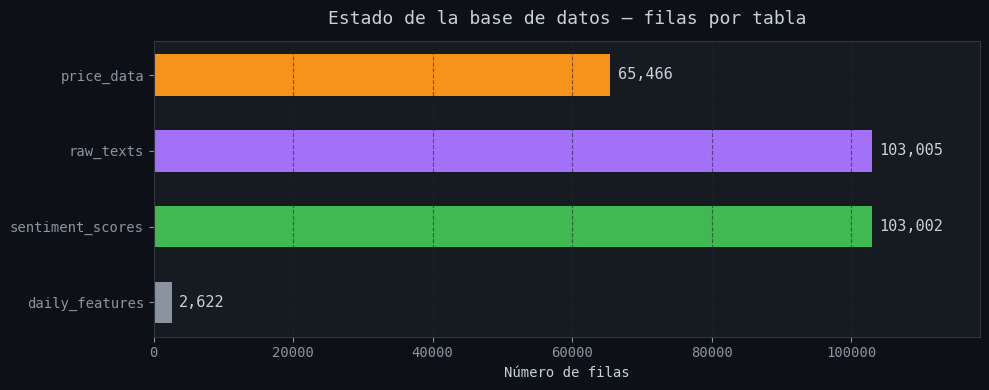

✅ Guardado: db_estado_tablas.png


In [3]:
# ── 1.2 Visualización: barras de filas por tabla ───────────────────────
with engine.connect() as conn:
    counts = {
        'price_data':       pd.read_sql(text("SELECT COUNT(*) AS n FROM price_data"), conn).iloc[0,0],
        'raw_texts':        pd.read_sql(text("SELECT COUNT(*) AS n FROM raw_texts"), conn).iloc[0,0],
        'sentiment_scores': pd.read_sql(text("SELECT COUNT(*) AS n FROM sentiment_scores"), conn).iloc[0,0],
        'daily_features':   pd.read_sql(text("SELECT COUNT(*) AS n FROM daily_features"), conn).iloc[0,0],
    }

fig, ax = plt.subplots(figsize=(10, 4))
colors = [ACCENT, SENT_COL, POS_COL, NEU_COL]
bars = ax.barh(list(counts.keys()), list(counts.values()), color=colors, height=0.55)

for bar, val in zip(bars, counts.values()):
    ax.text(bar.get_width() + max(counts.values()) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=11, color='#c9d1d9')

ax.set_xlabel('Número de filas')
ax.set_title('Estado de la base de datos — filas por tabla', fontsize=13, color='#c9d1d9', pad=12)
ax.set_xlim(0, max(counts.values()) * 1.15)
ax.grid(axis='x')
ax.invert_yaxis()
fig.tight_layout()
plt.savefig('db_estado_tablas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: db_estado_tablas.png')

---
## 2. Cobertura de fuentes de texto

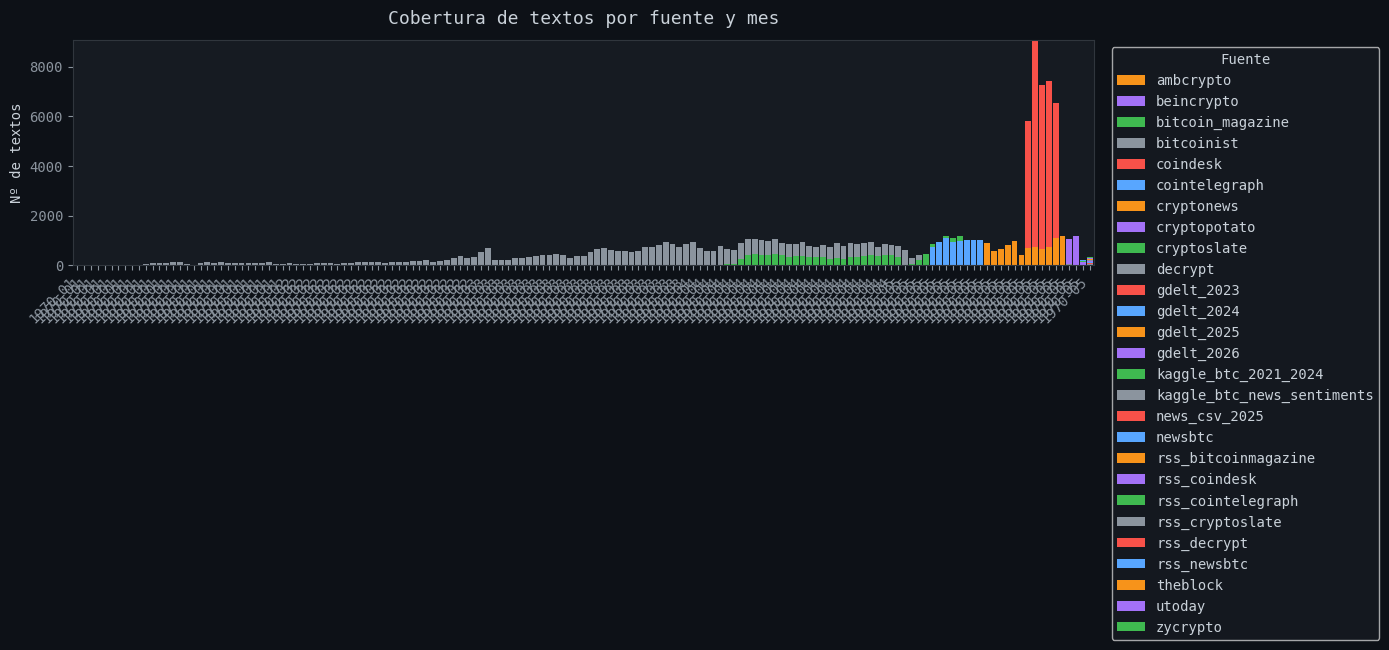

In [4]:
# ── 2.1 Textos por fuente y por mes ───────────────────────────────────
with engine.connect() as conn:
    df_cov = pd.read_sql(text("""
        SELECT
            DATE_TRUNC('month', timestamp)::date AS mes,
            source,
            COUNT(*) AS n
        FROM raw_texts
        GROUP BY mes, source
        ORDER BY mes, source
    """), conn)

df_cov['mes'] = pd.to_datetime(df_cov['mes'])
pivot = df_cov.pivot(index='mes', columns='source', values='n').fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
palette = [ACCENT, SENT_COL, POS_COL, NEU_COL, NEG_COL, '#58a6ff']
pivot.plot(kind='bar', stacked=True, ax=ax,
           color=palette[:len(pivot.columns)], width=0.85)

ax.set_title('Cobertura de textos por fuente y mes', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('Nº de textos')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend(title='Fuente', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.savefig('cobertura_fuentes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Evolución del sentimiento a lo largo del tiempo

In [5]:
# ── 3.1 Cargar daily_features ─────────────────────────────────────────
with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT date, close, returns, label,
               sentiment_avg, sentiment_std, sentiment_count,
               fear_greed, rsi_14, macd
        FROM daily_features
        WHERE asset = 'BTC'
        ORDER BY date ASC
    """), conn)

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df_sent = df.dropna(subset=['sentiment_avg'])  # solo días con texto

print(f'Total días: {len(df)} | Días con sentimiento: {len(df_sent)}')
print(f'Desde: {df.index.min().date()} → Hasta: {df.index.max().date()}')

Total días: 2622 | Días con sentimiento: 2602
Desde: 2019-01-01 → Hasta: 2026-03-06


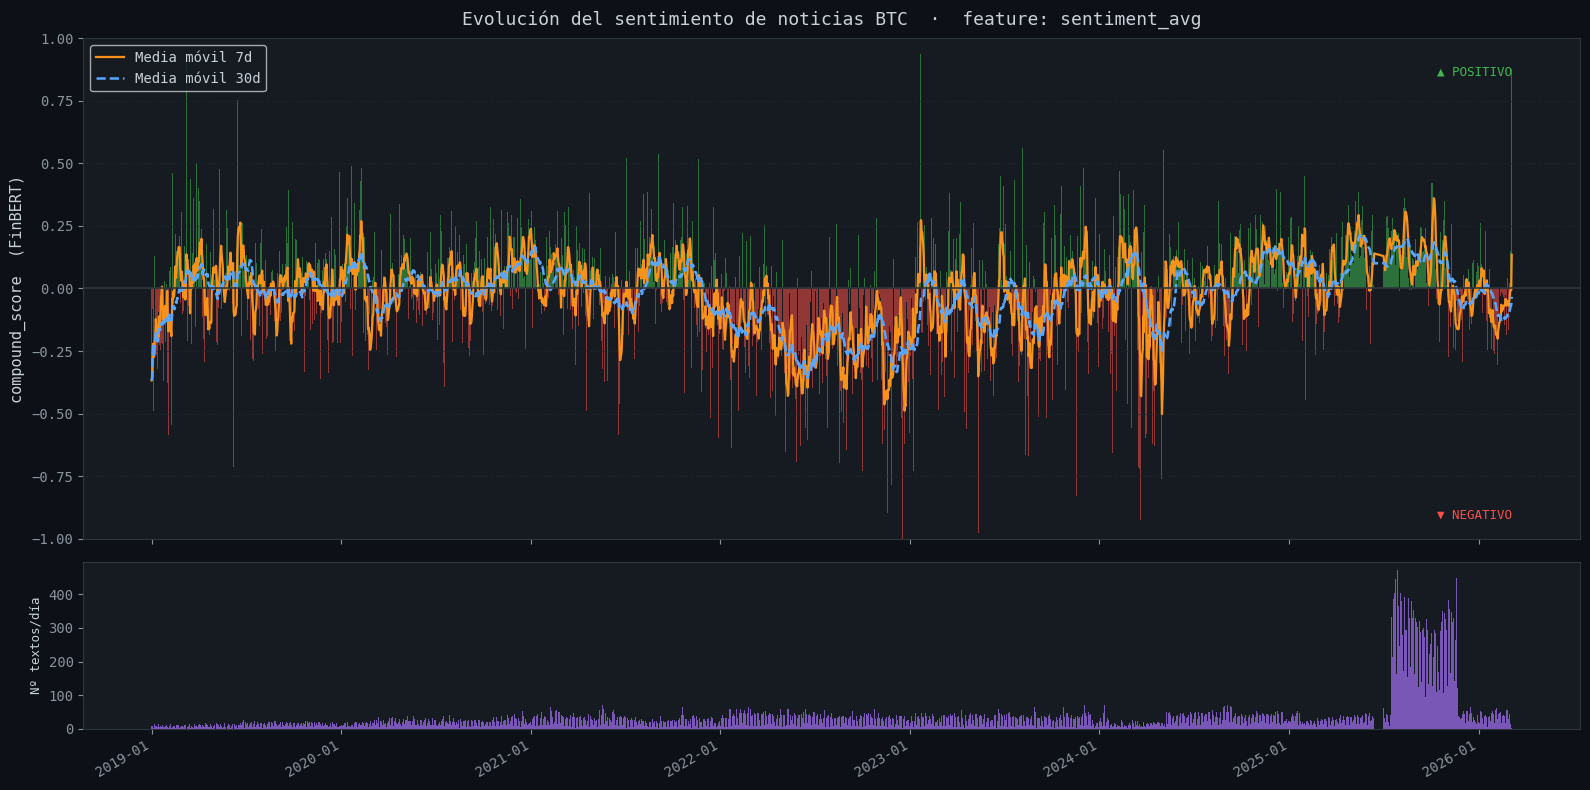

✅ Guardado: sentiment_evolucion.png


In [6]:
# ── 3.2 Sentimiento diario + media móvil 7 días ────────────────────────
# Esta es la gráfica principal del sentimiento como feature

roll7  = df_sent['sentiment_avg'].rolling(7,  min_periods=1).mean()
roll30 = df_sent['sentiment_avg'].rolling(30, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

# — Panel superior: barras coloreadas por signo + MMs
ax = axes[0]
colors_bar = [POS_COL if v > 0 else NEG_COL for v in df_sent['sentiment_avg']]
ax.bar(df_sent.index, df_sent['sentiment_avg'], color=colors_bar, alpha=0.55, width=1.0)
ax.plot(df_sent.index, roll7,  color=ACCENT,   lw=1.6, label='Media móvil 7d')
ax.plot(df_sent.index, roll30, color='#58a6ff', lw=1.8, label='Media móvil 30d', linestyle='--')
ax.axhline(0, color='#30363d', lw=1.2)
ax.set_ylabel('compound_score  (FinBERT)', fontsize=11)
ax.set_title('Evolución del sentimiento de noticias BTC  ·  feature: sentiment_avg',
             fontsize=13, pad=10)
ax.legend(loc='upper left')
ax.set_ylim(-1, 1)
ax.grid(axis='y')

# Etiquetas de zona positiva/negativa
ax.text(df_sent.index[-1], 0.85, '▲ POSITIVO', ha='right', color=POS_COL, fontsize=9)
ax.text(df_sent.index[-1], -0.92, '▼ NEGATIVO', ha='right', color=NEG_COL, fontsize=9)

# — Panel inferior: volumen de textos procesados ese día
ax2 = axes[1]
ax2.bar(df_sent.index, df_sent['sentiment_count'], color=SENT_COL, alpha=0.7, width=1.0)
ax2.set_ylabel('Nº textos/día', fontsize=9)
ax2.set_xlabel('')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30, ha='right')

fig.tight_layout()
plt.savefig('sentiment_evolucion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: sentiment_evolucion.png')

---
## 4. Sentimiento vs Precio BTC

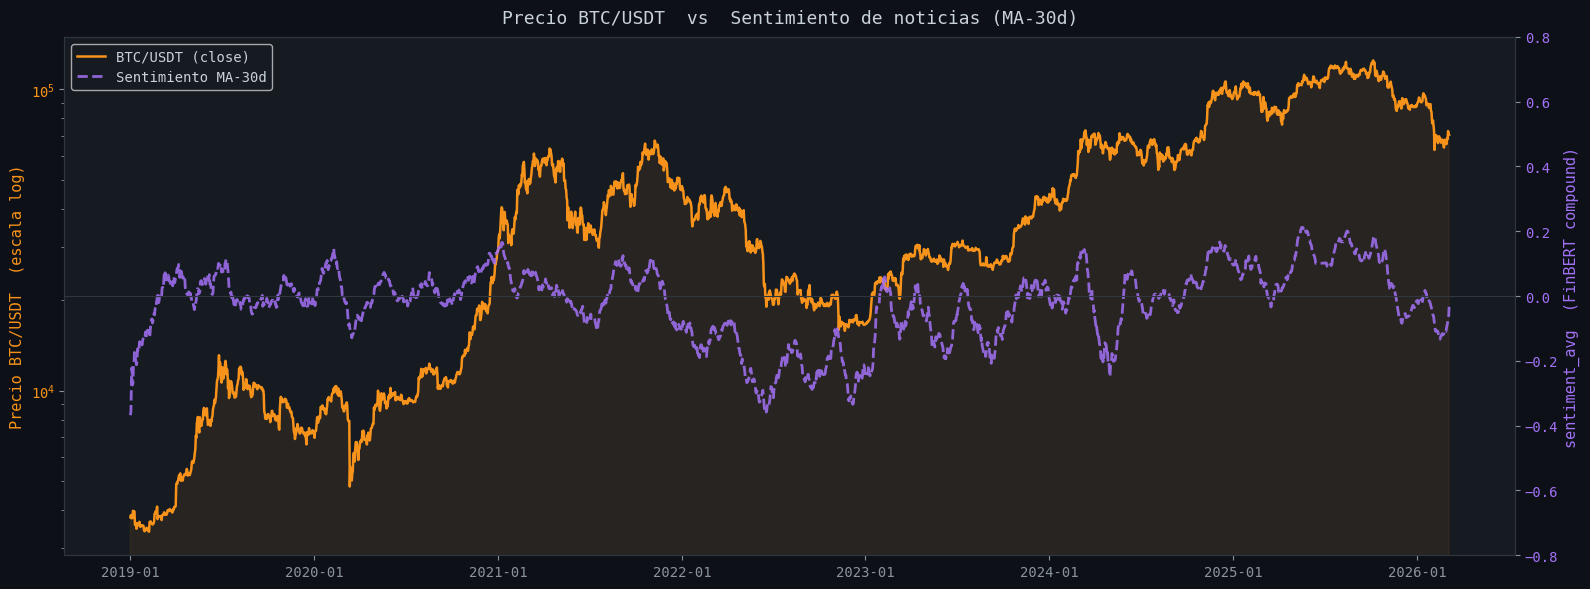

✅ Guardado: sentiment_vs_precio.png


In [7]:
# ── 4.1 Doble eje: precio BTC vs sentiment_avg ────────────────────────

fig, ax1 = plt.subplots(figsize=(16, 6))

# Precio BTC
ax1.plot(df.index, df['close'], color=ACCENT, lw=1.8, label='BTC/USDT (close)', zorder=3)
ax1.fill_between(df.index, df['close'], alpha=0.08, color=ACCENT)
ax1.set_yscale('log')
ax1.set_ylabel('Precio BTC/USDT  (escala log)', color=ACCENT, fontsize=11)
ax1.tick_params(axis='y', labelcolor=ACCENT)

# Sentimiento — eje secundario
ax2 = ax1.twinx()
ax2.plot(df_sent.index, roll30, color=SENT_COL, lw=2.0,
         label='Sentimiento MA-30d', linestyle='--', alpha=0.85)
ax2.axhline(0, color='#30363d', lw=0.8)
ax2.set_ylabel('sentiment_avg  (FinBERT compound)', color=SENT_COL, fontsize=11)
ax2.tick_params(axis='y', labelcolor=SENT_COL)
ax2.set_ylim(-0.8, 0.8)

ax1.set_title('Precio BTC/USDT  vs  Sentimiento de noticias (MA-30d)', fontsize=13, pad=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30, ha='right')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

fig.tight_layout()
plt.savefig('sentiment_vs_precio.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: sentiment_vs_precio.png')

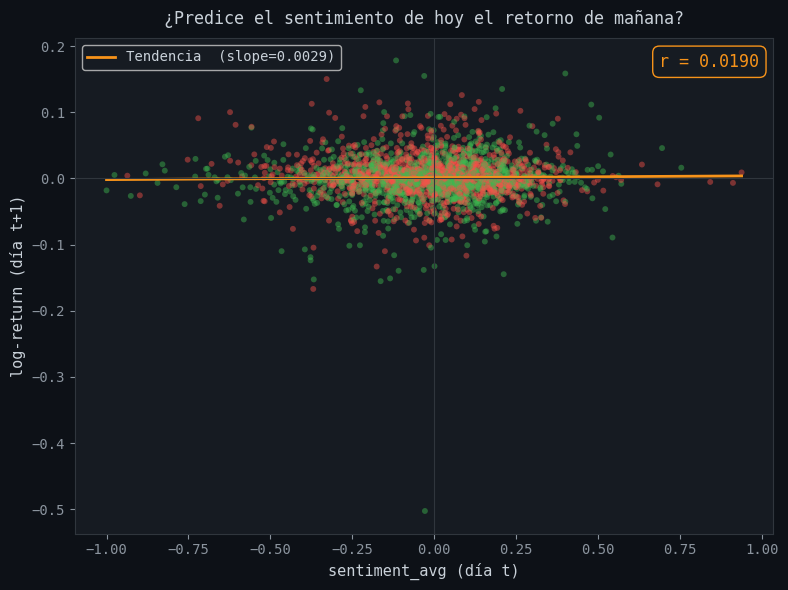

Correlación sentiment_avg → next_return: 0.0190


In [17]:
# ── 4.2 Scatter: sentiment_avg vs retorno del día siguiente ───────────
# ¿Predice el sentimiento de hoy el movimiento de mañana?

df_scatter = df_sent[['sentiment_avg', 'returns', 'label']].copy()
df_scatter['next_return'] = df_scatter['returns'].shift(-1)
df_scatter = df_scatter.dropna()

fig, ax = plt.subplots(figsize=(8, 6))
scatter_colors = [POS_COL if l == 1 else NEG_COL for l in df_scatter['label'].shift(-1).fillna(0)]
ax.scatter(df_scatter['sentiment_avg'], df_scatter['next_return'],
           c=scatter_colors, alpha=0.45, s=18, edgecolors='none')

# Línea de tendencia
m, b = np.polyfit(df_scatter['sentiment_avg'], df_scatter['next_return'], 1)
x_line = np.linspace(df_scatter['sentiment_avg'].min(), df_scatter['sentiment_avg'].max(), 100)
ax.plot(x_line, m*x_line + b, color=ACCENT, lw=2, label=f'Tendencia  (slope={m:.4f})')

ax.axhline(0, color='#30363d', lw=0.8)
ax.axvline(0, color='#30363d', lw=0.8)
ax.set_xlabel('sentiment_avg (día t)', fontsize=11)
ax.set_ylabel('log-return (día t+1)', fontsize=11)
ax.set_title('¿Predice el sentimiento de hoy el retorno de mañana?', fontsize=12, pad=10)
ax.legend()

# Correlación de Pearson
corr = df_scatter['sentiment_avg'].corr(df_scatter['next_return'])
ax.text(0.98, 0.97, f'r = {corr:.4f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=12, color=ACCENT,
        bbox=dict(facecolor='#161b22', edgecolor=ACCENT, boxstyle='round,pad=0.4'))

fig.tight_layout()
plt.savefig('sentiment_scatter_retorno.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Correlación sentiment_avg → next_return: {corr:.4f}')

---
## 5. Análisis adicionales

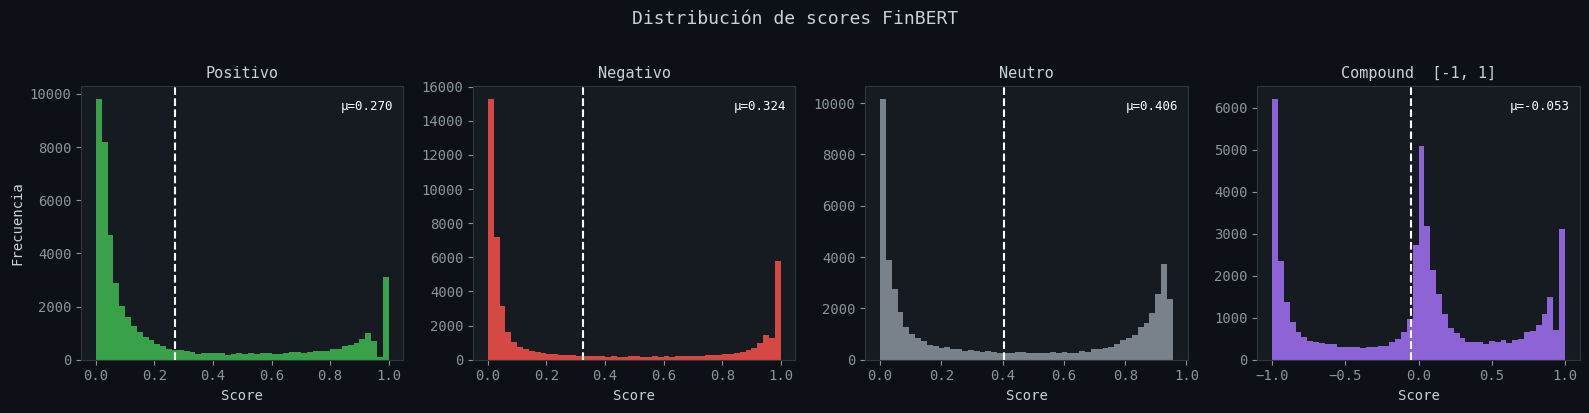

In [9]:
# ── 5.1 Distribución de scores FinBERT (positivo / negativo / neutro) ─
with engine.connect() as conn:
    df_scores = pd.read_sql(text("""
        SELECT score_positive, score_negative, score_neutral, compound_score
        FROM sentiment_scores
        LIMIT 50000
    """), conn)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
params = [
    ('score_positive', POS_COL,  'Positivo'),
    ('score_negative', NEG_COL,  'Negativo'),
    ('score_neutral',  NEU_COL,  'Neutro'),
    ('compound_score', SENT_COL, 'Compound  [-1, 1]'),
]
for ax, (col, color, title) in zip(axes, params):
    ax.hist(df_scores[col], bins=50, color=color, alpha=0.85, edgecolor='none')
    ax.axvline(df_scores[col].mean(), color='white', lw=1.5, linestyle='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Score')
    ax.set_ylabel('Frecuencia' if ax == axes[0] else '')
    ax.text(0.97, 0.95, f'μ={df_scores[col].mean():.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='white')

fig.suptitle('Distribución de scores FinBERT', fontsize=13, y=1.02)
fig.tight_layout()
plt.savefig('distribucion_scores_finbert.png', dpi=150, bbox_inches='tight')
plt.show()

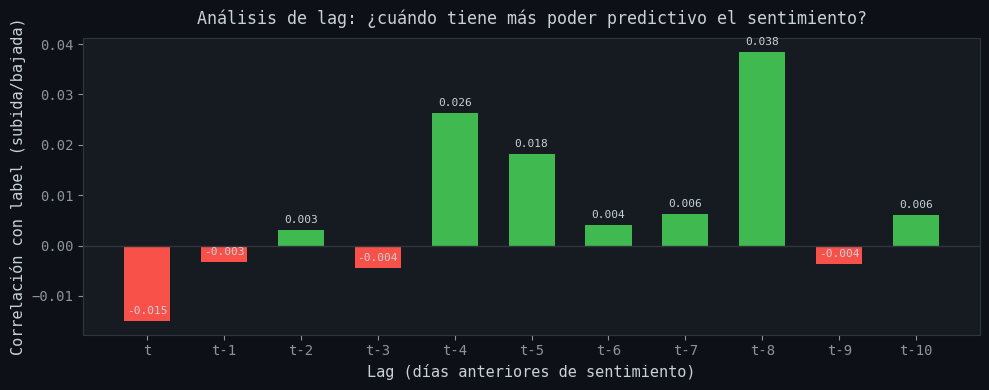

✅ Guardado: sentiment_lag_analysis.png
Lag con mayor correlación: t-8 (0.0385)


In [10]:
# ── 5.2 Análisis de lag: correlación sentiment(t-k) → label(t) ────────
# ¿Con cuántos días de desfase tiene más poder predictivo el sentimiento?

df_lag = df_sent[['sentiment_avg', 'label']].dropna()
max_lag = 10
lags   = range(0, max_lag + 1)
corrs  = [df_lag['sentiment_avg'].shift(k).corr(df_lag['label']) for k in lags]

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = [POS_COL if c > 0 else NEG_COL for c in corrs]
bars = ax.bar(lags, corrs, color=bar_colors, width=0.6)
ax.axhline(0, color='#30363d', lw=1)
ax.set_xticks(list(lags))
ax.set_xticklabels([f't-{k}' if k > 0 else 't' for k in lags])
ax.set_xlabel('Lag (días anteriores de sentimiento)', fontsize=11)
ax.set_ylabel('Correlación con label (subida/bajada)', fontsize=11)
ax.set_title('Análisis de lag: ¿cuándo tiene más poder predictivo el sentimiento?', fontsize=12, pad=10)

for bar, c in zip(bars, corrs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{c:.3f}', ha='center', va='bottom', fontsize=8, color='#c9d1d9')

fig.tight_layout()
plt.savefig('sentiment_lag_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: sentiment_lag_analysis.png')
print(f'Lag con mayor correlación: t-{corrs.index(max(corrs, key=abs))} ({max(corrs, key=abs):.4f})')

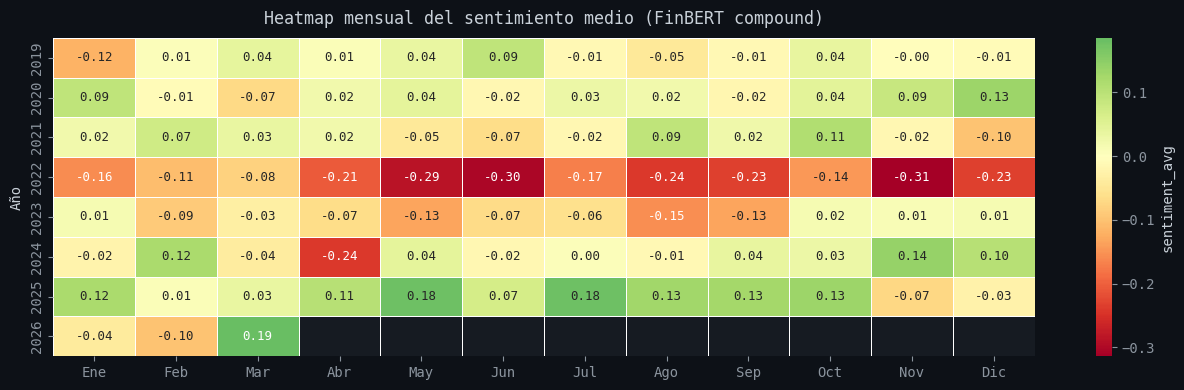

✅ Guardado: sentiment_heatmap_mensual.png


In [11]:
# ── 5.3 Heatmap mensual del sentimiento promedio ───────────────────────
# ¿Hay patrones estacionales en el sentimiento?

df_heat = df_sent[['sentiment_avg']].copy()
df_heat['year']  = df_heat.index.year
df_heat['month'] = df_heat.index.month
pivot_heat = df_heat.groupby(['year', 'month'])['sentiment_avg'].mean().unstack()
pivot_heat.columns = ['Ene','Feb','Mar','Abr','May','Jun',
                       'Jul','Ago','Sep','Oct','Nov','Dic'][:len(pivot_heat.columns)]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot_heat, ax=ax, cmap='RdYlGn', center=0,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'sentiment_avg'},
            annot_kws={'size': 9})
ax.set_title('Heatmap mensual del sentimiento medio (FinBERT compound)', fontsize=12, pad=10)
ax.set_xlabel('')
ax.set_ylabel('Año')
fig.tight_layout()
plt.savefig('sentiment_heatmap_mensual.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: sentiment_heatmap_mensual.png')

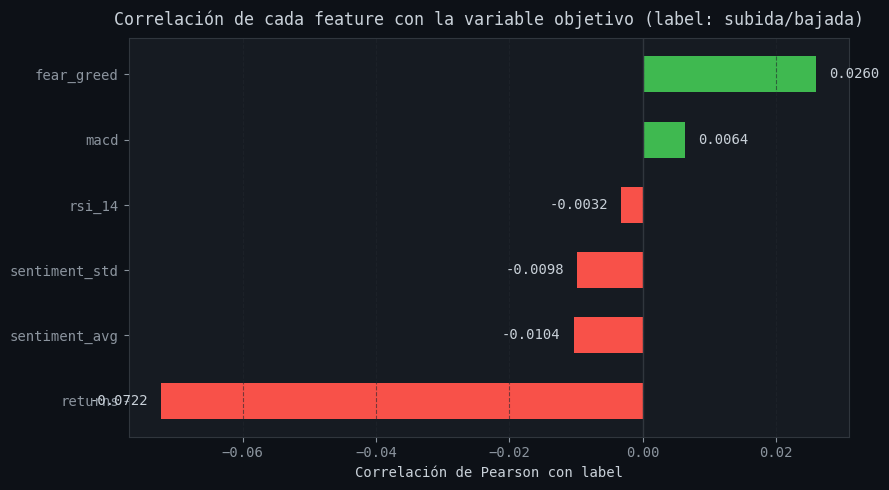

✅ Guardado: correlacion_features_label.png


In [12]:
# ── 5.4 Correlación cruzada entre TODAS las features y la variable objetivo ─

features_cols = ['rsi_14', 'macd', 'sentiment_avg', 'sentiment_std',
                 'fear_greed', 'returns']
df_corr = df[features_cols + ['label']].dropna()

corr_label = df_corr.corr()['label'].drop('label').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [POS_COL if v > 0 else NEG_COL for v in corr_label]
bars = ax.barh(corr_label.index, corr_label.values, color=bar_colors, height=0.55)
ax.axvline(0, color='#30363d', lw=1)

for bar, v in zip(bars, corr_label.values):
    offset = 0.002 if v >= 0 else -0.002
    ax.text(v + offset, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=10, color='#c9d1d9')

ax.set_title('Correlación de cada feature con la variable objetivo (label: subida/bajada)',
             fontsize=12, pad=10)
ax.set_xlabel('Correlación de Pearson con label')
ax.grid(axis='x')
fig.tight_layout()
plt.savefig('correlacion_features_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: correlacion_features_label.png')

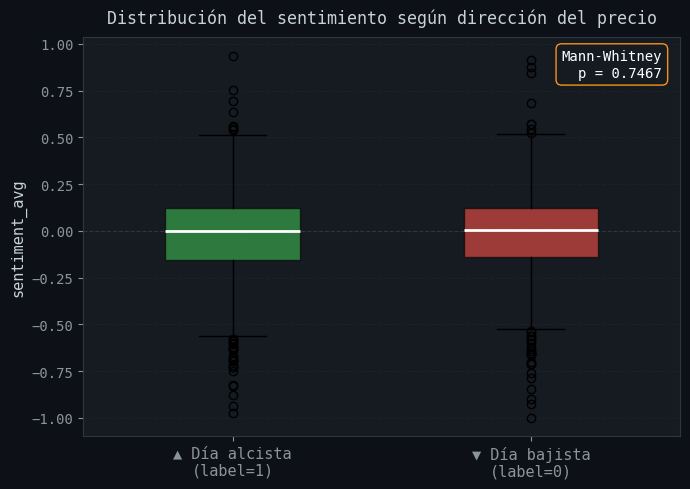

Test Mann-Whitney (días alcistas > bajistas):  p = 0.7467
→ No significativo (p≥0.05)


In [13]:
# ── 5.5 Box plot: sentimiento en días alcistas vs bajistas ─────────────
# ¿El sentimiento es significativamente diferente según la dirección del precio?

df_box = df_sent[['sentiment_avg', 'label']].dropna()
df_box['Dirección'] = df_box['label'].map({1: '▲ Alcista', 0: '▼ Bajista'})

fig, ax = plt.subplots(figsize=(7, 5))
groups = [df_box.loc[df_box['label']==1, 'sentiment_avg'],
          df_box.loc[df_box['label']==0, 'sentiment_avg']]
bp = ax.boxplot(groups, patch_artist=True, widths=0.45,
                medianprops=dict(color='white', lw=2))
for patch, color in zip(bp['boxes'], [POS_COL, NEG_COL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_xticklabels(['▲ Día alcista\n(label=1)', '▼ Día bajista\n(label=0)'], fontsize=11)
ax.set_ylabel('sentiment_avg', fontsize=11)
ax.set_title('Distribución del sentimiento según dirección del precio', fontsize=12, pad=10)
ax.axhline(0, color='#30363d', lw=0.8, linestyle='--')
ax.grid(axis='y')

# Test estadístico Mann-Whitney
from scipy import stats
stat, pval = stats.mannwhitneyu(groups[0], groups[1], alternative='greater')
ax.text(0.97, 0.97, f'Mann-Whitney\np = {pval:.4f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        color='white',
        bbox=dict(facecolor='#161b22', edgecolor=ACCENT, boxstyle='round,pad=0.4'))

fig.tight_layout()
plt.savefig('sentiment_boxplot_alcista_bajista.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Test Mann-Whitney (días alcistas > bajistas):  p = {pval:.4f}')
print('→ Significativo (p<0.05)' if pval < 0.05 else '→ No significativo (p≥0.05)')

---
## 6. Resumen exportable para la memoria del TFG

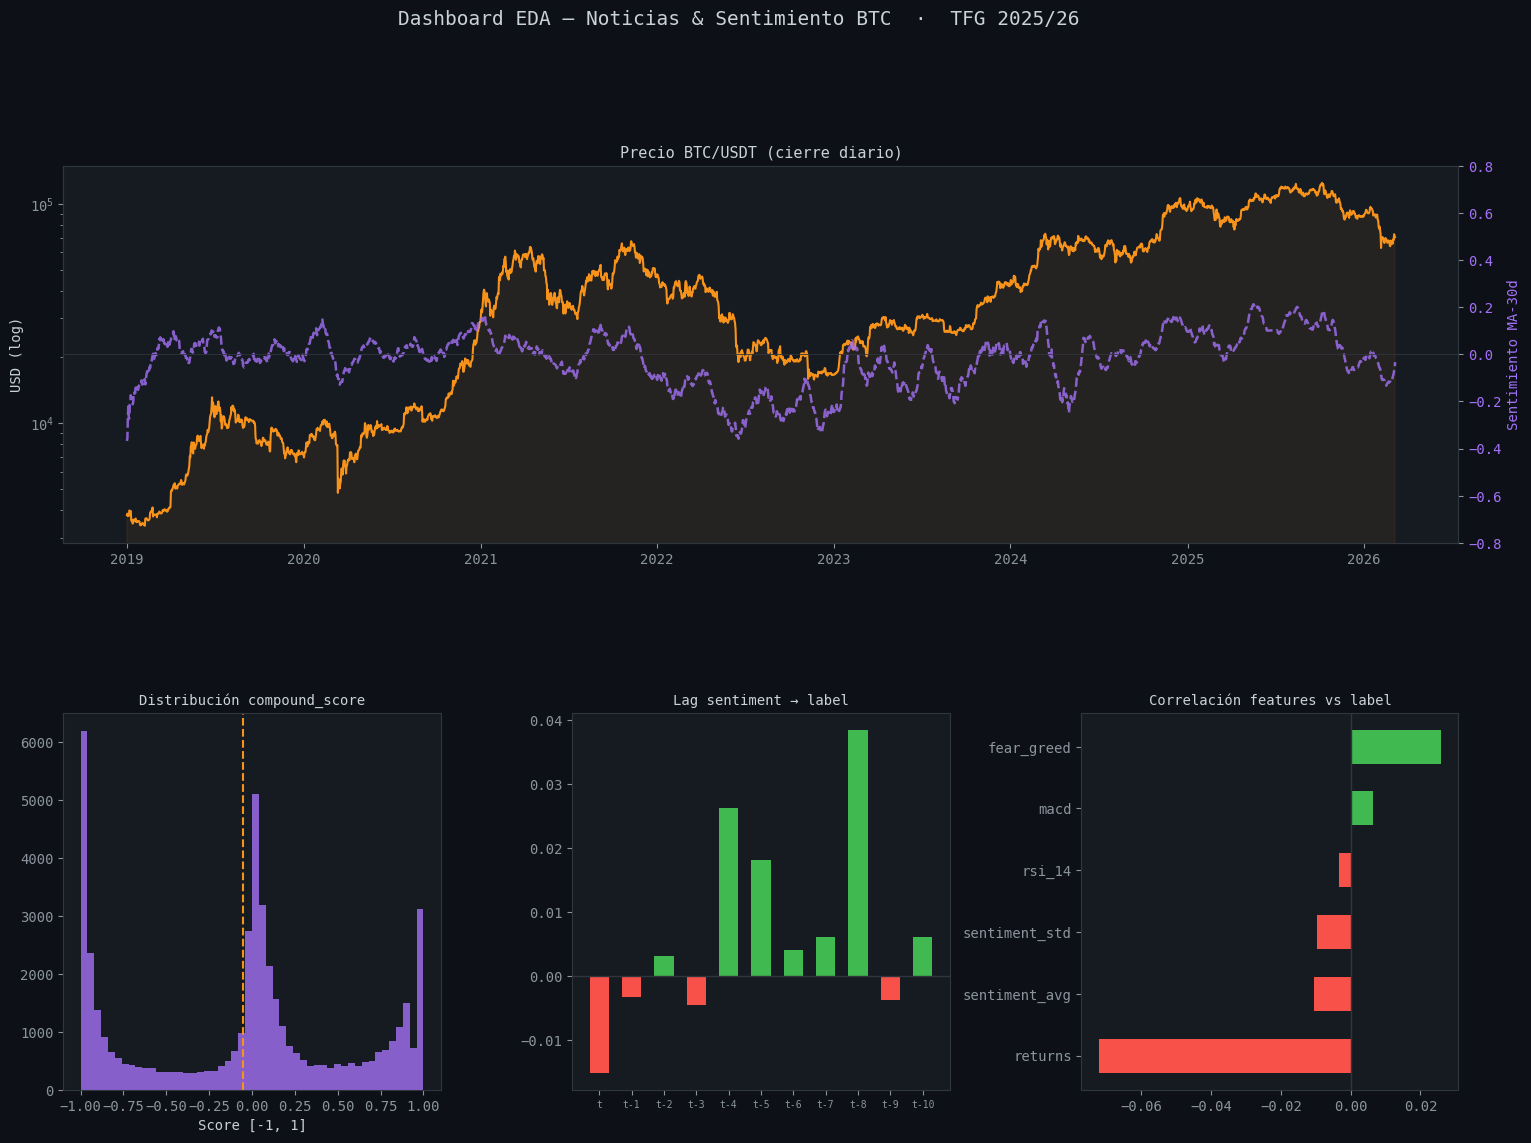

✅ Guardado: dashboard_eda_sentimiento.png


In [14]:
# ── 6. Panel resumen 2x3 con las gráficas clave ───────────────────────

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# A) Precio BTC
ax_a = fig.add_subplot(gs[0, :])
ax_a.plot(df.index, df['close'], color=ACCENT, lw=1.5)
ax_a.fill_between(df.index, df['close'], alpha=0.07, color=ACCENT)
ax_a.set_yscale('log')
ax_a.set_title('Precio BTC/USDT (cierre diario)', fontsize=11)
ax_a.set_ylabel('USD (log)')
ax_ax2 = ax_a.twinx()
ax_ax2.plot(df_sent.index, roll30, color=SENT_COL, lw=1.8, linestyle='--', alpha=0.8)
ax_ax2.set_ylabel('Sentimiento MA-30d', color=SENT_COL)
ax_ax2.tick_params(axis='y', labelcolor=SENT_COL)
ax_ax2.set_ylim(-0.8, 0.8)
ax_ax2.axhline(0, color='#30363d', lw=0.6)

# B) Distribución compound_score
ax_b = fig.add_subplot(gs[1, 0])
ax_b.hist(df_scores['compound_score'], bins=50, color=SENT_COL, alpha=0.8, edgecolor='none')
ax_b.axvline(df_scores['compound_score'].mean(), color=ACCENT, lw=1.5, linestyle='--')
ax_b.set_title('Distribución compound_score', fontsize=10)
ax_b.set_xlabel('Score [-1, 1]')

# C) Lag analysis
ax_c = fig.add_subplot(gs[1, 1])
ax_c.bar(lags, corrs, color=[POS_COL if c > 0 else NEG_COL for c in corrs], width=0.6)
ax_c.axhline(0, color='#30363d', lw=1)
ax_c.set_xticks(list(lags))
ax_c.set_xticklabels([f't-{k}' if k > 0 else 't' for k in lags], fontsize=7)
ax_c.set_title('Lag sentiment → label', fontsize=10)

# D) Correlaciones features
ax_d = fig.add_subplot(gs[1, 2])
ax_d.barh(corr_label.index, corr_label.values,
          color=[POS_COL if v > 0 else NEG_COL for v in corr_label.values], height=0.55)
ax_d.axvline(0, color='#30363d', lw=1)
ax_d.set_title('Correlación features vs label', fontsize=10)

fig.suptitle('Dashboard EDA — Noticias & Sentimiento BTC  ·  TFG 2025/26',
             fontsize=14, y=1.01, color='#c9d1d9')

plt.savefig('dashboard_eda_sentimiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: dashboard_eda_sentimiento.png')